# Car Detection — OpenVINO (Intel geti deployment)

**Flow:** Install → Imports & config → Load model → Image inference → Latency → Video → Display video → Gradio → Benchmark

**Model:** ATSS-MobileNetV2 OpenVINO INT8, 992×800 input

## 1. Install (run once)

In [1]:
import subprocess, os
_req = os.path.join("1", "requirements.txt") if os.path.exists("1") else "requirements.txt"
subprocess.run(["pip", "install", "-q", "-r", _req], check=True)

CompletedProcess(args=['pip', 'install', '-q', '-r', 'requirements.txt'], returncode=0)

## 2. Imports and config

**Paths — change as needed:**

In [10]:
import os
import sys
import cv2
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Ensure import from folder 1 when run from project root
_dir = os.path.dirname(os.path.abspath("."))
if os.path.basename(os.getcwd()) != "1" and os.path.exists(os.path.join(os.getcwd(), "1")):
    sys.path.insert(0, os.path.join(os.getcwd(), "1"))
from ov_utils import (
    load_model, run_detection_ov, run_detection_video, get_sample_images,
    get_available_devices, benchmark_latency_ms, get_inference_tensor,
    get_model_name, benchmark_throughput_streams,
)

# BASE = folder 1 (media, models, output live here)
BASE = os.getcwd() if os.path.basename(os.getcwd()) == "1" else os.path.join(os.getcwd(), "1")

# --- Paths (1/, media/, models/INT8/, output/) ---
MODEL_DIR = os.path.join(BASE, "models", "INT8")
# MODEL_DIR = os.path.join(BASE, "models", "FP16")  # if you add FP16
# MODEL_DIR = os.path.join(BASE, "models", "FP32")  # if you add FP32

IMAGE_PATH = os.path.join(BASE, "media", "sample_image.jpg")
if not os.path.exists(IMAGE_PATH):
    samples = get_sample_images(os.path.join(BASE, "media"))
    IMAGE_PATH = samples[0][1] if samples else IMAGE_PATH

VIDEO_PATH = os.path.join(BASE, "media", "Car_video.mp4")
OUTPUT_VIDEO_PATH = os.path.join(BASE, "output", "Car_video_out.avi")
os.makedirs(os.path.join(BASE, "output"), exist_ok=True)

THRESH = 0.225

devices = get_available_devices(exclude=["NPU"])  # NPU throws error for this model
default_dev = "CPU" if "CPU" in devices else (devices[0] if devices else "CPU")
device_dropdown = widgets.Dropdown(options=devices, value=default_dev, description="Device:")

## 3. Select device & load model

In [11]:
load_out = widgets.Output()

def _load_model(*args):
    global compiled, config, labels, model_name
    with load_out:
        load_out.clear_output(wait=True)
        compiled, config = load_model(MODEL_DIR, device=device_dropdown.value)
        labels = config.get("model_parameters", {}).get("labels", "car")
        model_name = get_model_name(MODEL_DIR)
        print(f"Loaded: {model_name} on {device_dropdown.value}")
        print(f"Labels: {labels}")

device_dropdown.observe(_load_model, names="value")
display(device_dropdown)
display(load_out)
_load_model()

Dropdown(description='Device:', options=('CPU', 'GPU'), value='CPU')

Output()

## 4. Image inference + display (with latency)

Detections: 5 | Latency: 34.24 ms


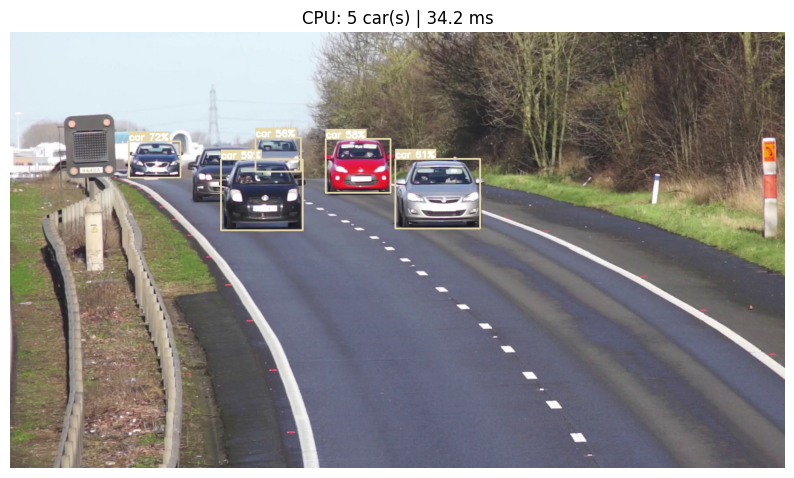

In [12]:
image = cv2.imread(IMAGE_PATH)
if image is None:
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")

boxes, result_img, lat_ms = run_detection_ov(compiled, image, thresh=THRESH, label=labels, return_latency=True)
print(f"Detections: {len(boxes)} | Latency: {lat_ms:.2f} ms")

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"{device_dropdown.value}: {len(boxes)} {labels}(s) | {lat_ms:.1f} ms")
plt.show()

## 5. Latency benchmark (optional)

In [13]:
tensor = get_inference_tensor(compiled, image)
avg_lat = benchmark_latency_ms(compiled, tensor, num_iter=50)
print(f"Avg latency: {avg_lat:.2f} ms")

Avg latency: 30.70 ms


## 6. Video inference

In [14]:
if os.path.exists(VIDEO_PATH):
    out, frames, fps = run_detection_video(
        compiled, VIDEO_PATH, output_path=OUTPUT_VIDEO_PATH,
        thresh=THRESH, label=labels, device=device_dropdown.value
    )
    print(f"Processed {frames} frames @ {fps:.1f} fps -> {OUTPUT_VIDEO_PATH}")
else:
    print(f"Video not found: {VIDEO_PATH}")

Processed 431 frames @ 30.0 fps -> C:\Users\anish\Cursor\Openvino\DevCon\geti_sdk-deployment\geti_sdk-deployment\1\output\Car_video_out.avi


## 7. Display video

Display: C:\Users\anish\Cursor\Openvino\DevCon\geti_sdk-deployment\geti_sdk-deployment\1\output\Car_video_out.gif


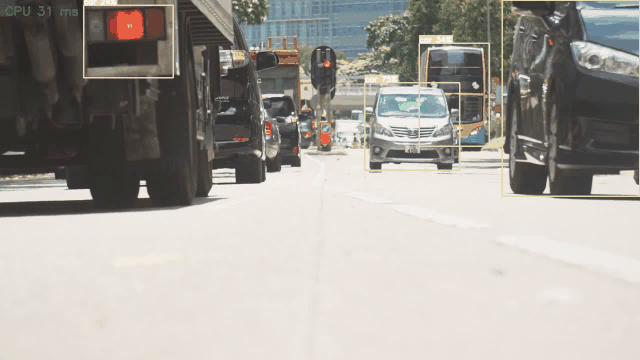

In [15]:
# Use GIF for reliable browser playback (AVI often shows black)
from IPython.display import Image, display as ipy_display
from ov_utils import convert_video_to_gif

gif_path = None
if os.path.exists(OUTPUT_VIDEO_PATH):
    gif_path = convert_video_to_gif(OUTPUT_VIDEO_PATH, max_frames=60, scale=0.5, fps=10)
elif os.path.exists(OUTPUT_VIDEO_PATH.replace(".avi", ".mp4")):
    mp4 = OUTPUT_VIDEO_PATH.replace(".avi", ".mp4")
    gif_path = convert_video_to_gif(mp4, max_frames=60, scale=0.5, fps=10)

if gif_path:
    print(f"Display: {gif_path}")
    ipy_display(Image(filename=gif_path))
else:
    print("Run video inference first (section 6).")

## 8. Gradio app

In [16]:
from app_gradio import create_demo
demo = create_demo()
demo.launch()

* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.


## 9. Performance benchmark (model name + 2 vs 4 streams)

In [ ]:
# Intel blue color variants
INTEL_BLUE = "#0071C5"
INTEL_LIGHT_BLUE = "#00A3E0"

results = benchmark_throughput_streams(MODEL_DIR, image, device_dropdown.value, stream_counts=(2, 4))
streams = [r[0] for r in results]
fps_vals = [r[1] for r in results]
lat_vals = [r[2] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = [INTEL_BLUE, INTEL_LIGHT_BLUE]
axes[0].bar(streams, fps_vals, color=colors)
axes[0].set_title("Throughput (FPS)")
axes[0].set_xlabel("Streams")
for i, v in enumerate(fps_vals):
    axes[0].text(streams[i], v + 0.5, f"{v:.1f}", ha="center", fontsize=10)
axes[1].bar(streams, lat_vals, color=colors)
axes[1].set_title("Latency (ms)")
axes[1].set_xlabel("Streams")
for i, v in enumerate(lat_vals):
    axes[1].text(streams[i], v + 1, f"{v:.1f}", ha="center", fontsize=10)
fig.suptitle(f"{model_name} on {device_dropdown.value}", fontsize=12)
plt.tight_layout()
plt.show()
